In [107]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms
import matplotlib.pyplot as plt
from math import ceil, floor
from datetime import datetime 
torch.manual_seed(123)
import torchvision
import math

# Model definition

In [108]:
device = (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
print(f"Training on device {device}.")

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
net = Net()

Training on device cpu.


## Localization


In [109]:
def localization_loss(y_pred, y_true):
    return torch.where(
        #Todo
        # ...
            # Detection loss
            # ..
            # Bounding box loss
            # ..
            # Classification loss
            # ..
    )

### Load data and preprocessing

In [ ]:
# TODO
# Load the data
def load_data():
    train = torch.load('data/localization_train.pt', weights_only=False)
    val = torch.load('data/localization_val.pt', weights_only=False)
    test = torch.load('data/localization_test.pt', weights_only=False)
    #norm_train, norm_val, norm_test = normalize(train, val, test)
    return train, val, test #norm_train, norm_val, norm_test

train, val, test = load_data()
print(f'Train size: {len(train)}')
print(f'Val size: {len(val)}')
print(f'Test size: {len(test)}')  
print("Label:", train.tensors[1][0])

labels = train.tensors[1]

# første indeks i label
class_ids = labels[:, 0]

total = len(labels)
no_object = (class_ids == 1).sum().item()
has_object = (class_ids != 1).sum().item()

print(f"Total samples: {total}")
print(f"No object: {no_object}")
print(f"Has object: {has_object}")




Train size: 59400
Val size: 6600
Test size: 11000
Label: tensor([1.0000, 0.6000, 0.2292, 0.3667, 0.4167, 4.0000])
tensor([1.0000, 0.6000, 0.2292, 0.3667, 0.4167])


### Normalize Images

In [111]:
# TODO
def normalize(data):
    tensors = data.tensors[0]  # Get the underlying tensor
    mean = tensors.mean(dim=0)    # Mean per feature
    std  = tensors.std(dim=0)     # Std per feature
    data_norm = (data - mean)/std
    return data_norm 


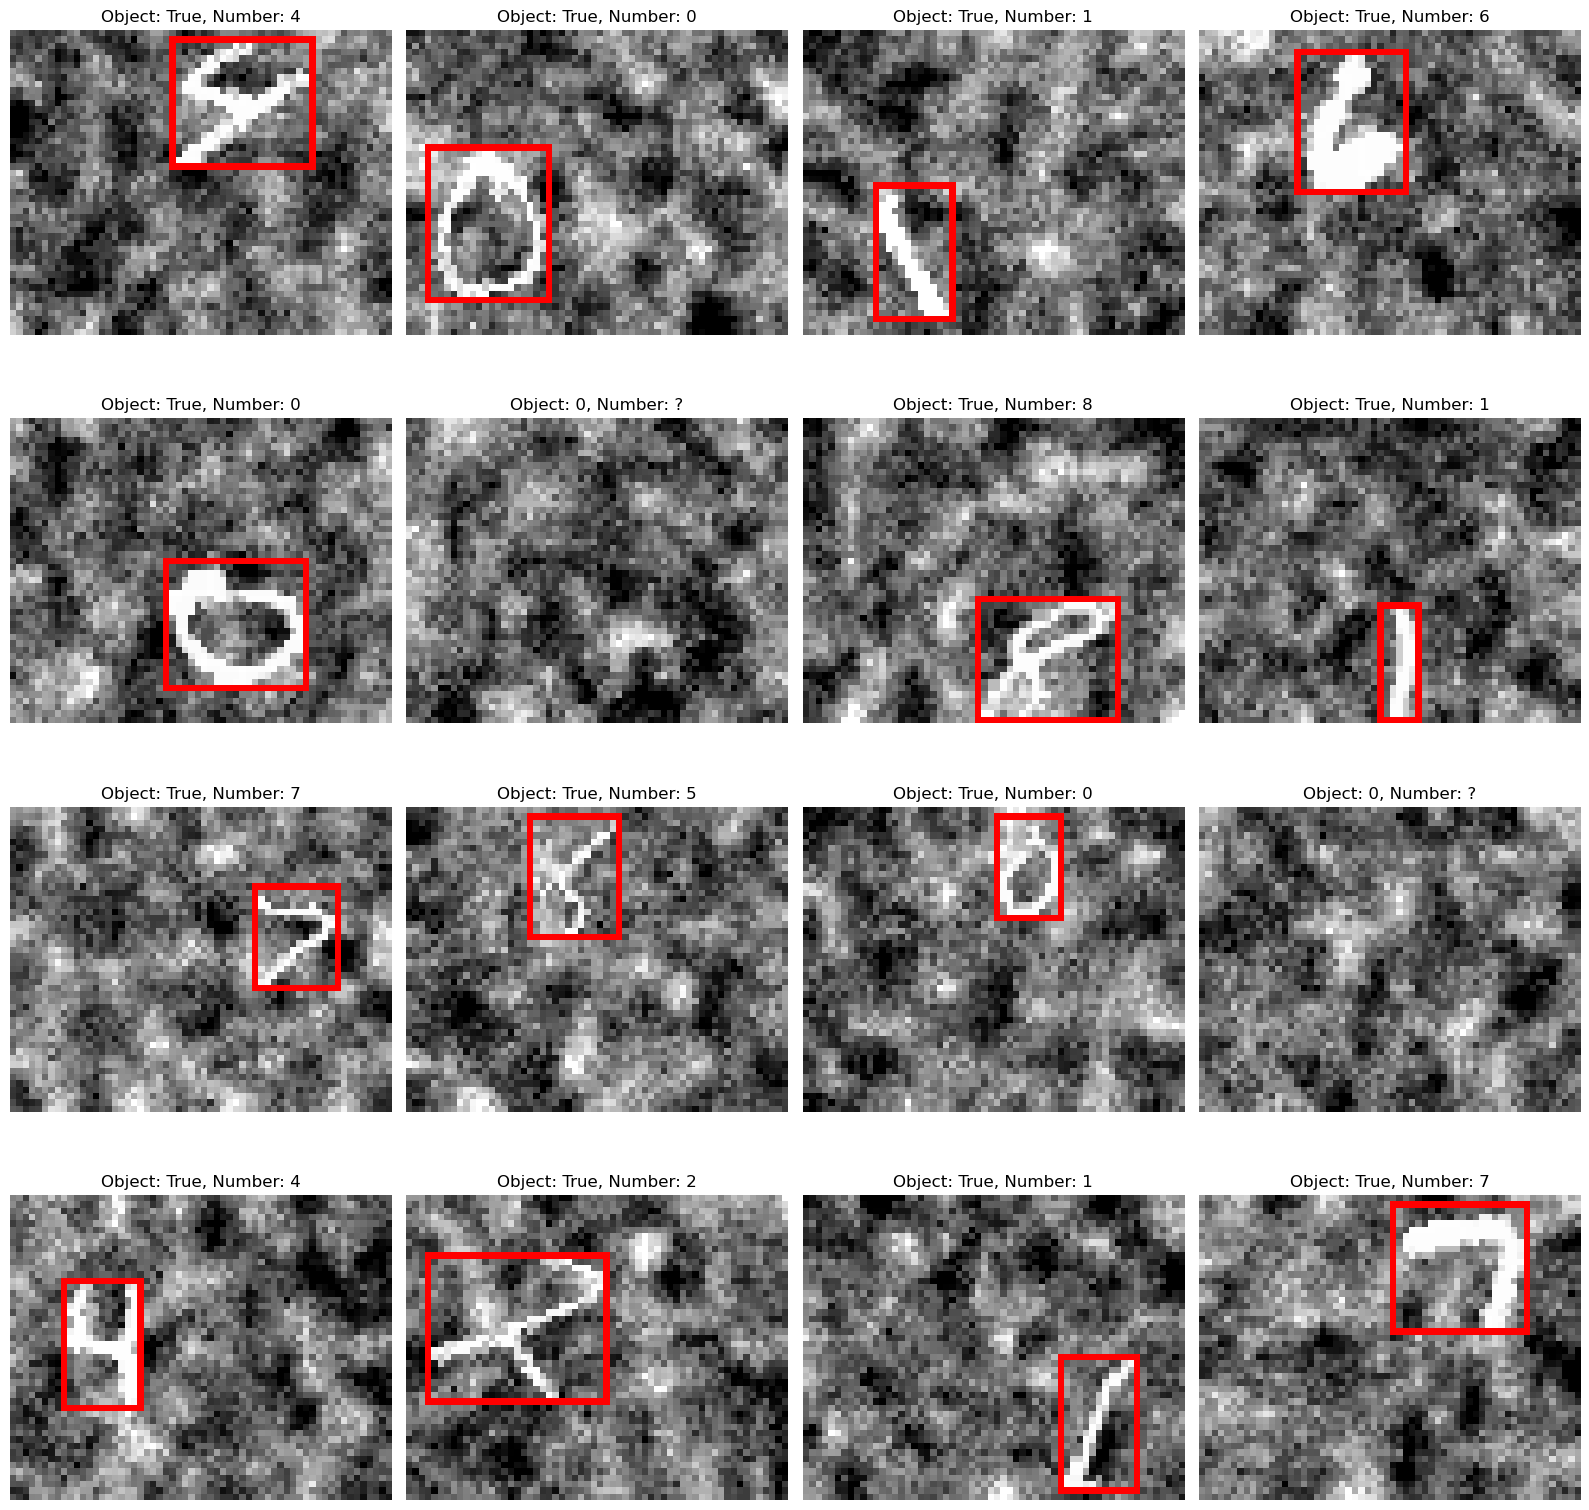

In [124]:
def get_drawn_image(ds, i=0):
    img = ds.tensors[0][i]          # [1,H,W], float [0,1]
    y   = ds.tensors[1][i].float()  # [6]
    H, W = img.shape[-2], img.shape[-1]

    # y[1:5] = (cx, cy, w, h) normalisert
    box = y[1:5].unsqueeze(0)                   # [1,4]
    box_xyxy = box_convert(box, "cxcywh", "xyxy")  # [1,4] normalisert

    # Skaler til pixels
    box_xyxy = box_xyxy * torch.tensor([W, H, W, H], dtype=torch.float32)

    # Gjør bildet klarere for visning 
    img_u8 = (img.clamp(0,1) * 255).to(torch.uint8).repeat(3, 1, 1)

    if int(y[0].item()) == 0:
        return img_u8.permute(1,2,0).numpy(), int(y[0].item()), '?'

    drawn = torchvision.utils.draw_bounding_boxes(img_u8, box_xyxy, colors="red", width=1)
    return drawn.permute(1,2,0).numpy(), bool(y[0].item()), int(y[-1].item())

import matplotlib.pyplot as plt

def show_samples(ds, n=7):
    cols = 4
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = axes.flatten()  

    for i in range(n):
        img, cls, number = get_drawn_image(ds, i)
        axes[i].imshow(img)
        axes[i].set_title(f"Object: {cls}, Number: {number}")
        axes[i].axis("off")

    # Skjul tomme subplot hvis n ikke fyller gridet
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train, 16)

### Training

In [ ]:
# TODO

### Predictions

In [ ]:
# TODO

### Model selection and evaluation

In [ ]:
def intersection(bb1, bb2):
    """
    Compute intersection between 2 bb, in global frame of ref
    """
    # TODO
   
def IoU(bb1, bb2):
    """
    Compute IoU given 2 bb (local or global)
    """
    #TODO
   
def compute_IoU_localization(model, loader, preprocessor):
    """
    Compute IoU performance of the model on the given dataset
    """
   #TODO

def compute_accuracy_localization(model, loader, preprocessor):
    """
    Compute accuracy of the model on the given dataset
    """
    #TODO
    